<a href="https://colab.research.google.com/github/kowsik005/All_ML_models/blob/main/hierarchical_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset shape: (300, 2)

First 5 rows:
   Feature_1  Feature_2
0  -7.430860  -7.899923
1  -7.912123  -7.341576
2  -1.522144   7.549274
3   4.378661   3.291702
4  -9.325377  -8.089813

Scaled data:
[[-1.17808295 -1.38679069]
 [-1.2751755  -1.30311925]
 [ 0.01397294  0.92836   ]
 [ 1.20443274  0.29033844]
 [-1.56029275 -1.41524685]]


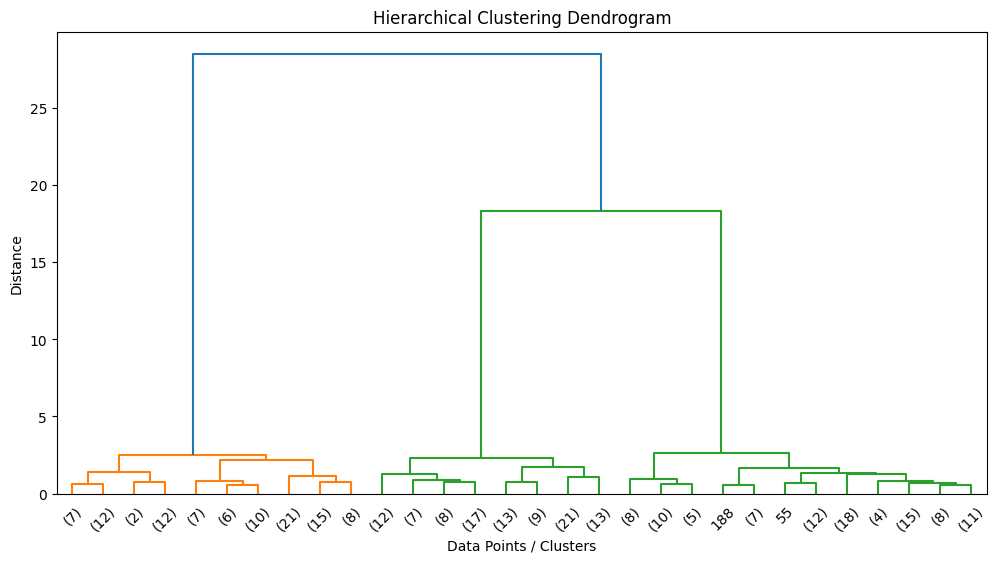


Clustered Data:
    Feature_1  Feature_2  Cluster
0   -7.430860  -7.899923        1
1   -7.912123  -7.341576        1
2   -1.522144   7.549274        2
3    4.378661   3.291702        0
4   -9.325377  -8.089813        1
5    5.669070   1.781243        0
6   -2.301381   9.476667        2
7    5.135397   1.296700        0
8   -3.084207   8.791495        2
9   -3.938762   9.802150        2
10  -3.231246  11.237020        2
11   5.068297   1.141678        0
12  -2.258561   6.662682        2
13  -4.207643   8.509512        2
14  -7.660398  -7.464660        1
15  -3.351661   8.621092        2
16  -8.832678  -6.822408        1
17   2.209708   2.196915        0
18  -2.392705  10.176660        2
19  -1.804969  11.642833        2

Cluster Distribution:
Cluster
0    100
1    100
2    100
Name: count, dtype: int64


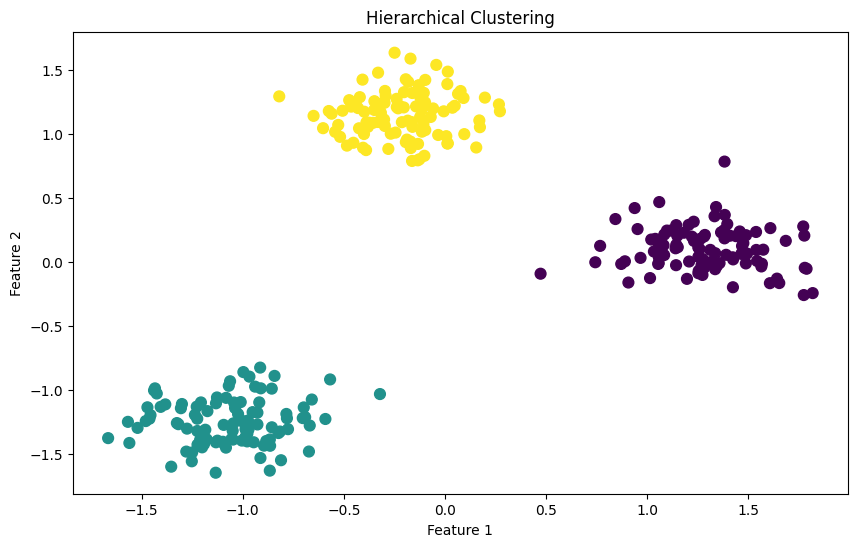


Silhouette Score: 0.8182


In [1]:
# ==========================================================
# HIERARCHICAL CLUSTERING - COMPLETE EXAMPLE
# ==========================================================

# 1. Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage


# ==========================================================
# 2. Create sample dataset
# ==========================================================

X, y = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.2,
    random_state=42
)

print("Dataset shape:", X.shape)


# ==========================================================
# 3. Convert to DataFrame
# ==========================================================

df = pd.DataFrame(
    X,
    columns=["Feature_1", "Feature_2"]
)

print("\nFirst 5 rows:")
print(df.head())


# ==========================================================
# 4. Feature Scaling
# ==========================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nScaled data:")
print(X_scaled[:5])


# ==========================================================
# 5. Create Dendrogram
# ==========================================================

linked = linkage(
    X_scaled,
    method="ward"
)

plt.figure(figsize=(12, 6))

dendrogram(
    linked,
    truncate_mode="lastp",
    p=30
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points / Clusters")
plt.ylabel("Distance")

plt.show()


# ==========================================================
# 6. Create Agglomerative Clustering Model
# ==========================================================

hc = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)


# ==========================================================
# 7. Train and Predict Clusters
# ==========================================================

cluster_labels = hc.fit_predict(X_scaled)

df["Cluster"] = cluster_labels


# ==========================================================
# 8. Display Clustered Data
# ==========================================================

print("\nClustered Data:")
print(df.head(20))


# ==========================================================
# 9. Count points in each cluster
# ==========================================================

print("\nCluster Distribution:")

print(
    df["Cluster"].value_counts().sort_index()
)


# ==========================================================
# 10. Visualize Clusters
# ==========================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=cluster_labels,
    s=60
)

plt.title("Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()


# ==========================================================
# 11. Calculate Silhouette Score
# ==========================================================

score = silhouette_score(
    X_scaled,
    cluster_labels
)

print("\nSilhouette Score:", round(score, 4))